In [110]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA Process 

In [111]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


(918, 12)

In [112]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

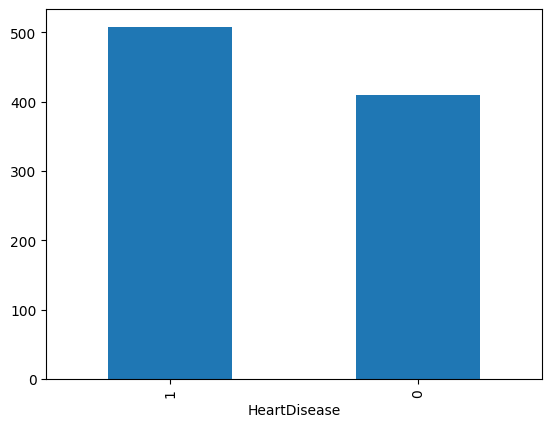

In [115]:
df["HeartDisease"].value_counts().plot(kind="bar")

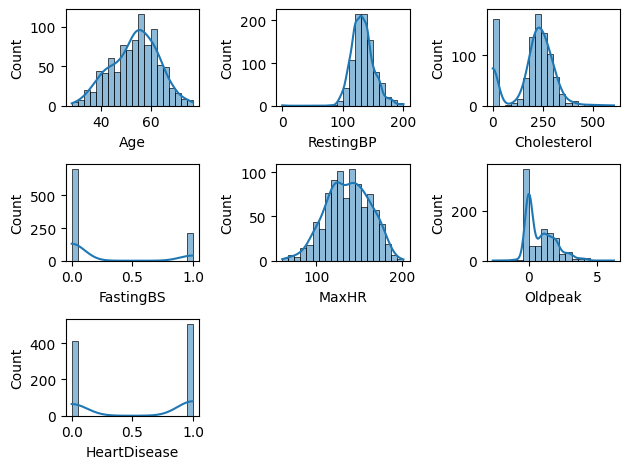

In [116]:
def plotting_graph(var,num):
    plt.subplot(3,3,num)
    sns.histplot(df[var],kde = True,bins = 20)
plotting_graph("Age",1)
plotting_graph("RestingBP",2)
plotting_graph("Cholesterol",3)
plotting_graph("FastingBS",4)
plotting_graph("MaxHR",5)
plotting_graph("Oldpeak",6)
plotting_graph("HeartDisease",7)
plt.tight_layout()

In [117]:
# Filling values of cholesterol with mean value .

ch_mean = df.loc[df["Cholesterol"] !=0,"Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)

In [118]:
# Filling values of resting bp with mean value .

resting_bp_mean = df.loc[df["RestingBP"] !=0,"RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0,ch_mean)
df["RestingBP"] = df["RestingBP"].round(2)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


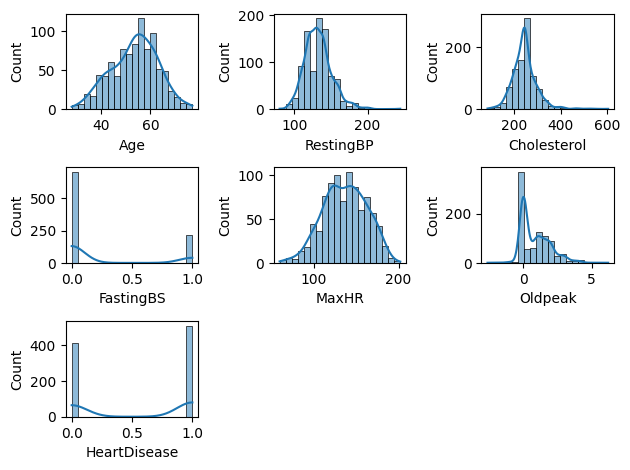

In [119]:
def plotting_graph(var,num):
    plt.subplot(3,3,num)
    sns.histplot(df[var],kde = True,bins = 20)
plotting_graph("Age",1)
plotting_graph("RestingBP",2)
plotting_graph("Cholesterol",3)
plotting_graph("FastingBS",4)
plotting_graph("MaxHR",5)
plotting_graph("Oldpeak",6)
plotting_graph("HeartDisease",7)
plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

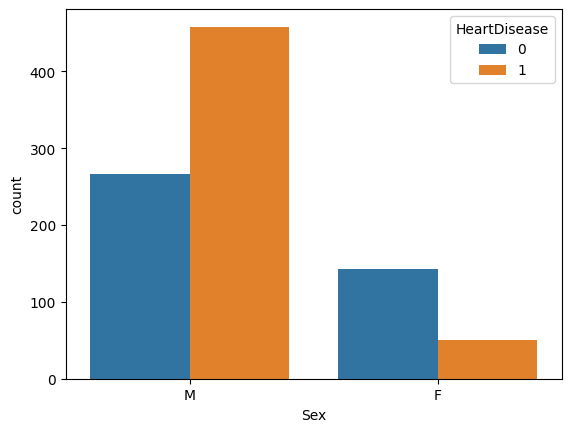

In [120]:
sns.countplot(data=df,x = "Sex",hue="HeartDisease" )

<Axes: xlabel='ChestPainType', ylabel='count'>

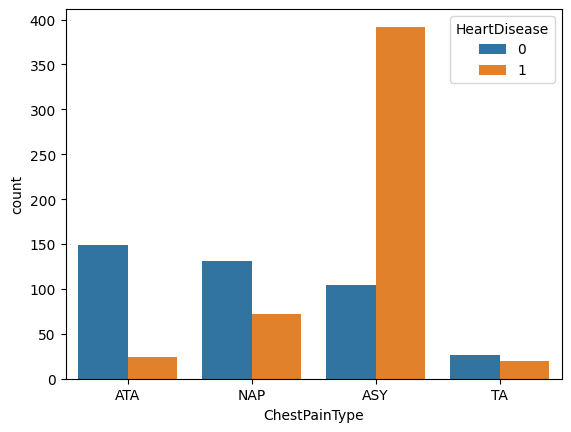

In [121]:
sns.countplot(data=df,x = "ChestPainType",hue="HeartDisease")

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

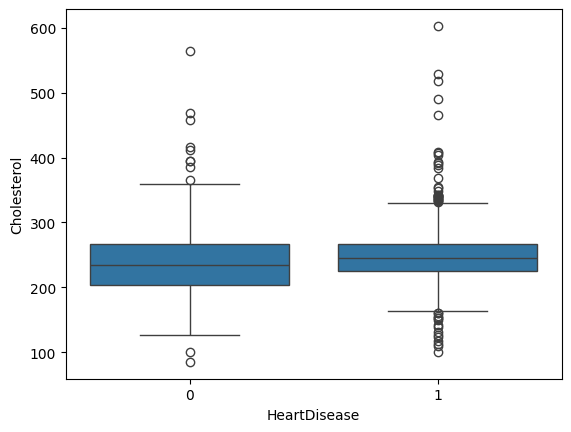

In [122]:
sns.boxplot(data=df,y = "Cholesterol",x = "HeartDisease")

<Axes: xlabel='HeartDisease', ylabel='Age'>

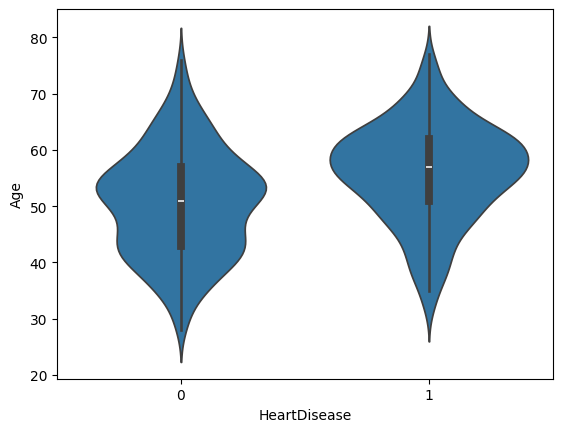

In [123]:
sns.violinplot(data=df,x = "HeartDisease",y = "Age" )

<Axes: >

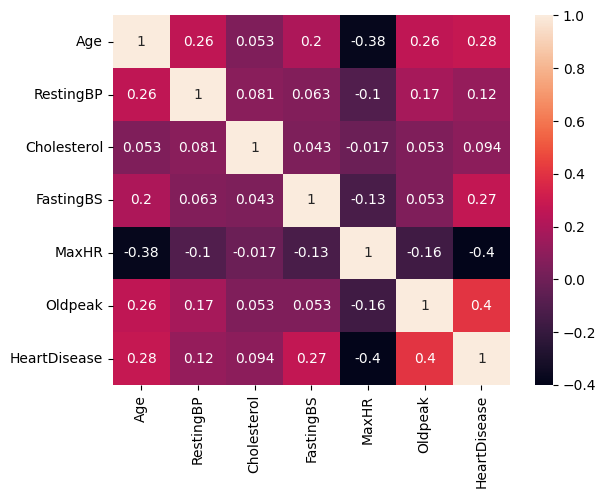

In [124]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing and Cleaning

In [125]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode = df_encode.astype(int)

In [126]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [127]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
